# C04 · Code walkthrough: turboshaft, engine deck, gearbox

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the fuel-to-shaft end of the series hybrid and the shaft-to-shaft gear trains,
plus the example code that fits the engine lapse and builds these components for the Halo.

| Module | Lines | What it holds |
|---|---|---|
| `powertrain/decks.py` | 92 | GASP_TS deck loader, the normalized part-power curve, the cubic least-squares fit |
| `powertrain/components/turboshaft.py` | 159 | three part-power submodels, the embedded 1,120 hp deck table and cubic, `DensityTemperatureLapse`, `SimpleTurboshaft` |
| `powertrain/components/gearbox.py` | 92 | `GearStageModel` (smooth stage count, efficiency, mass factor), `Gearbox` |
| `examples/xv15_performance.py` (excerpt) | L44-52 | `fit_lapse_exponent`: density exponent n from the XV-15 power-available curve |
| `examples/xv15_hot_day.py` (excerpt) | L31-76 | temperature exponent m from the 95 F curve, `xv15_lapse_model` |
| `examples/halo_sizing.py` (excerpt) | L624-758, L1116-1143, L1299-1304 | AFDD gearbox masses, `stage_mass_ratio`, generator step-up, engine mass regression |

**Who imports what.**
- `decks.py` imports only `aerosandbox.numpy` and `units`. Nothing in `src/` or `examples/` imports it: it is an
  offline tool. Its only importer is `tests/powertrain/test_decks.py`. Its output is embedded as numbers in
  `turboshaft.py` (L75-84).
- `turboshaft.py` imports AeroSandbox and `aerosandbox.library.power_turboshaft.thermal_efficiency_turboshaft`. It is
  imported by `powertrain/ports.py`, `powertrain/topologies.py`, `powertrain/compatibility.py`, and by the examples
  `halo_sizing.py`, `xv15_performance.py`, `xv15_hot_day.py`, `xv15_reference.py`, `series_hybrid_point*.py`.
- `gearbox.py` imports only `aerosandbox.numpy`. Same importers in `powertrain/`, plus `halo_sizing.py`
  (`Gearbox`, `GearStageModel`) and `xv15_reference.py`.

**The engine deck file is not in the repo.** `data/engines/` is gitignored (`.gitignore`, "User-supplied engine and
propeller data (not committed; see plan 014)"). The deck enters the model only through the 10-point median curve
and its cubic fit, both embedded in `turboshaft.py`. Below, the loader is exercised on a synthetic deck written in
the same format.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from examples.halo_sizing import HaloRequirements, build_halo_aircraft

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
# The sized v3.6 aircraft, rebuilt with numbers (the solved design) instead of optimization variables.
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
instances = {name: inst.component for name, inst in aircraft.powertrain.topology.instances.items()}
counts = {name: inst.count for name, inst in aircraft.powertrain.topology.instances.items()}
engine, gearbox, generator_gearbox = instances["turboshaft"], instances["gearbox"], instances["generator_gearbox"]
d = ref.design
print(f"turboshaft x{counts['turboshaft']}: rated {d.power_rated_turboshaft_W / u.hp:.0f} hp, "
      f"bare {d.mass_turboshaft_bare_kg:.1f} kg, installed {engine.get_mass():.1f} kg")
print(f"rotor gearbox x{counts['gearbox']}: ratio {gearbox.reduction_ratio:.3f}, eta {gearbox.efficiency:.4f}, "
      f"rated {gearbox.power_rated_W / 1e3:.0f} kW, {gearbox.get_mass():.1f} kg")
print(f"generator step-up x{counts['generator_gearbox']}: ratio {generator_gearbox.reduction_ratio:.4f} "
      f"(1/{1 / generator_gearbox.reduction_ratio:.3f}), eta {generator_gearbox.efficiency:.4f}, "
      f"rated {generator_gearbox.power_rated_W / 1e3:.0f} kW, {generator_gearbox.get_mass():.1f} kg")

turboshaft x2: rated 1120 hp, bare 184.2 kg, installed 210.9 kg
rotor gearbox x2: ratio 4.528, eta 0.9800, rated 757 kW, 146.2 kg
generator step-up x2: ratio 0.2183 (1/4.581), eta 0.9800, rated 835 kW, 72.1 kg


---
## 1. `powertrain/decks.py`

The bottom layer of this group: pure data processing, no optimization variables anywhere. Shown in three chunks.

In [2]:
show_source("src/aircraft_closure/powertrain/decks.py", 1, 36)

# src/aircraft_closure/powertrain/decks.py  lines 1-36
   1  """Engine decks: parsing and derived curves (lowest layer: data, no optimization).
   2  
   3  GASP_TS-style turboshaft decks list corrected shaft power, tailpipe thrust
   4  and corrected fuel flow on a full Mach x altitude x throttle grid, with
   5  `# key: value` metadata lines before the column header. Throttle is the deck's
   6  turbine-temperature parameter (e.g. 20 = flight idle, 50 = `t4max`), not a
   7  power fraction.
   8  
   9  Only the normalised part-power curve is derived here. sfc = fuel flow /
  10  shaft power, and sfc / sfc at maximum throttle is independent of the
  11  correction convention (both columns carry the same correction), so it can be
  12  used even where a deck's altitude scaling is in doubt.
  13  """
  14  from dataclasses import dataclass, field
  15  from typing import Any
  16  
  17  import aerosandbox.numpy as np
  18  import aerosandbox.tools.units as u
  19  
  20  
  21  @datac

**Line by line**

- **L1-13 module docstring.** Three facts the rest of the file depends on:
  - a GASP_TS turboshaft deck is a full Mach x altitude x throttle grid of *corrected* shaft power, tailpipe thrust
    and corrected fuel flow, with `# key: value` metadata lines before a column header (L3-5);
  - "throttle" is the deck's turbine-temperature parameter (20 = flight idle, 50 = `t4max`), **not** a power
    fraction (L5-7). That is why the derived curve is re-expressed against power fraction;
  - only the normalized part-power curve is used (L9-12). Corrected power and corrected fuel flow carry the same
    correction factor (both divided by the same delta·sqrt(theta) in the usual convention), so their ratio sfc is
    unaffected, and sfc / sfc at max throttle on the same row is unaffected too. Plan 014 found the deck's altitude
    columns non-monotonic after correction (1,120 hp at sea level, flat about 900 hp from 1,500 to 10,000 ft, 953 hp at
    15,000 ft; `docs/decisions/014`), so the deck's absolute levels are not trusted. The normalized curve is.
- **L14-18 imports.** `aerosandbox.numpy` is used for plain NumPy work here (`argsort`, `interp`, `unique`,
  `median`, `lstsq`); nothing in this file is meant to be symbolic.
- **L21-29 `TurboshaftDeck`.** Frozen dataclass of flat 1-D column arrays, one entry per deck line, in SI after
  loading: Mach [-], altitude [m], throttle [deck units], corrected shaft power [W], tailpipe thrust [N], corrected
  fuel flow [kg/s], and a `metadata` dict (strings). `field(default_factory=dict)` avoids a shared mutable default.
  The fields are typed `Any` because they are arrays.
- **L31-36 `row(mach, altitude_m)`.** One (Mach, altitude) line of the grid:
  - L33 boolean mask by **exact float equality**. This is safe only because the caller passes values taken from
    the same arrays (`np.unique(deck.mach)` in L75); a hand-typed altitude in metres would not match the converted
    `ft * 0.3048` values;
  - L34 sort the masked rows by throttle, L35-36 return throttle, power and fuel flow in that order. After the sort,
    index `-1` is the maximum throttle, which `part_power_curve` relies on.

In [3]:
show_source("src/aircraft_closure/powertrain/decks.py", 39, 61)

# src/aircraft_closure/powertrain/decks.py  lines 39-61
  39  def load_gasp_turboshaft_deck(path):
  40      """Columns: Mach, altitude [ft], throttle, shaft power [hp], tailpipe thrust [lbf], fuel flow [lb/h]."""
  41      metadata, values = {}, []
  42      header_seen = False
  43      for line in open(path, encoding="utf-8"):
  44          text = line.strip()
  45          if not text:
  46              continue
  47          if text.startswith("#"):
  48              key, _, value = text[1:].partition(":")
  49              if value.strip():
  50                  metadata[key.strip()] = value.strip()
  51              continue
  52          if not header_seen:
  53              header_seen = True
  54              continue
  55          values.append(np.array(text.split(","), dtype=float))
  56      data = np.array(values)
  57      return TurboshaftDeck(
  58          mach=data[:, 0], altitude_m=data[:, 1] * u.foot, throttle=data[:, 2],
  59          power_shaft_corrected_W=data[

- **L39-40** columns in deck units: Mach, altitude [ft], throttle, shaft power [hp], tailpipe thrust [lbf], fuel
  flow [lb/h].
- **L41-55 the parser**, one pass over the lines:
  - L44-46 blank lines skipped;
  - L47-51 a `#` line is metadata: `partition(":")` splits at the first colon; a `#` line with nothing after the
    colon (or no colon, like `# created for tests`) is a comment and is dropped (L49);
  - L52-54 the first non-comment line is the column header and is skipped (`header_seen`). The header text is not
    parsed: column order is fixed by convention;
  - L55 every other line is split on commas and converted to floats.
- **L56-61** stack into a 2-D array and convert units once: `u.foot` (0.3048 m), `u.hp` (745.7 W), `u.lbf`, and
  `u.lbm / u.hour` for lb/h to kg/s.
- **L43** `open(path, ...)` is iterated without a `with` block, so the file handle is closed only when garbage
  collected. Harmless for a one-shot offline loader (listed under Findings).

**Run it** on a synthetic deck in the same format (the real deck is not committed). Two (Mach, altitude) rows,
two throttles each; this is the deck of `tests/powertrain/test_decks.py`.

In [4]:
import tempfile, os
from aircraft_closure.powertrain.decks import load_gasp_turboshaft_deck, part_power_curve, fit_cubic_part_power
synthetic = '''# created for tests
# sls_horsepower: 100.0
# t4max: 50.0

Mach Number (input), Altitude (ft, input), Throttle (input), Shaft Power Corrected (hp, output), Tailpipe Thrust (lbf, output), Fuel Flow (lb/h, output)
0.0, 0.0, 20.0, 20.0, 1.0, 30.0
0.0, 0.0, 50.0, 100.0, 2.0, 60.0
0.0, 1000.0, 50.0, 100.0, 2.0, 70.0
0.0, 1000.0, 20.0, 25.0, 1.0, 40.0
'''
handle, deck_path = tempfile.mkstemp(suffix=".csv")
with os.fdopen(handle, "w") as stream:
    stream.write(synthetic)
deck = load_gasp_turboshaft_deck(deck_path)
os.remove(deck_path)
print("metadata:", deck.metadata)
print("altitude_m:", deck.altitude_m, " power_W:", deck.power_shaft_corrected_W)
throttle, power_W, fuel_kg_s = deck.row(0.0, 1000 * u.foot)
print("row(0, 1000 ft) sorted by throttle:", throttle, power_W / u.hp, fuel_kg_s / (u.lbm / u.hour))
check("comment line without a value is dropped; key: value lines kept",
      deck.metadata == {"sls_horsepower": "100.0", "t4max": "50.0"})
check("units converted once at load (100 hp -> 74,570 W, 60 lb/h -> kg/s)",
      abs(deck.power_shaft_corrected_W[1] - 100 * u.hp) < 1e-9 and abs(deck.fuel_flow_corrected_kg_s[1] - 60 * u.lbm / 3600) < 1e-15)
check("row() sorts by throttle even when the file does not (L34)", list(throttle) == [20.0, 50.0])
print("row(0, 304.8) matches:", len(deck.row(0.0, 304.8)[0]), "entries;  row(0, 1000 * u.foot):", len(deck.row(0.0, 1000 * u.foot)[0]))

metadata: {'sls_horsepower': '100.0', 't4max': '50.0'}
altitude_m: [  0.    0.  304.8 304.8]  power_W: [14913.99443002 74569.97215008 74569.97215008 18642.49303752]
row(0, 1000 ft) sorted by throttle: [20. 50.] [ 25. 100.] [40. 70.]
PASS  comment line without a value is dropped; key: value lines kept
PASS  units converted once at load (100 hp -> 74,570 W, 60 lb/h -> kg/s)
PASS  row() sorts by throttle even when the file does not (L34)
row(0, 304.8) matches: 0 entries;  row(0, 1000 * u.foot): 2


The last line shows the exact-equality mask: 1000 ft is stored as `1000 * 0.3048`, which is not bit-identical to
the literal `304.8`, so the hand-typed altitude finds no rows and `part_power_curve` would silently skip it. Always
index rows with values taken from the deck (as L75-76 do).

In [5]:
show_source("src/aircraft_closure/powertrain/decks.py", 64, 92)

# src/aircraft_closure/powertrain/decks.py  lines 64-92
  64  @dataclass(frozen=True)
  65  class PartPowerCurve:
  66      power_fraction: Any
  67      sfc_ratio_median: Any
  68      sfc_ratio_min: Any
  69      sfc_ratio_max: Any
  70  
  71  
  72  def part_power_curve(deck, power_fractions):
  73      """sfc / sfc_max against power / power_max, interpolated per (Mach, altitude) row, then summarised."""
  74      ratios = []
  75      for mach in np.unique(deck.mach):
  76          for altitude_m in np.unique(deck.altitude_m):
  77              _, power_W, fuel_kg_s = deck.row(mach, altitude_m)
  78              if len(power_W) == 0:
  79                  continue
  80              sfc = fuel_kg_s / power_W
  81              ratios.append(np.interp(power_fractions, power_W / power_W[-1], sfc / sfc[-1]))
  82      ratios = np.array(ratios)
  83      return PartPowerCurve(np.array(power_fractions), np.median(ratios, axis=0), np.min(ratios, axis=0),
  84                            np

- **L64-69 `PartPowerCurve`**: the requested power fractions and, at each, the median, minimum and maximum of
  sfc / sfc_max across all (Mach, altitude) rows. The min and max are the row spread (about +/-10-15 % on the real
  deck, plan 014); only the median is used downstream.
- **L72-84 `part_power_curve(deck, power_fractions)`**:
  - L75-79 loop over every Mach and every altitude value; L78-79 skip combinations not present in the deck (a sparse
    grid would otherwise give empty rows);
  - L80 sfc = fuel flow / shaft power on the row, in kg/J (corrected / corrected, so the correction cancels);
  - L81 normalize both axes by the **last** entry, the maximum throttle (sorted in `row`), then `np.interp`
    evaluates the row's sfc ratio at the requested fractions. `np.interp` needs increasing x, so
    this assumes power rises monotonically with throttle on every row, and it clamps outside the row's range (a row
    whose idle point is at 25 % power returns its 25 % value at 10 %);
  - L82-84 stack the rows and reduce across them with median, min, max (axis 0 = rows).

$$\text{power fraction} = \frac{P}{P(\text{throttle}_{max})}, \qquad \text{sfc ratio} = \frac{\text{sfc}}{\text{sfc}(\text{throttle}_{max})}$$

- **L87-92 `fit_cubic_part_power`**: linear least squares for the cubic in the variable x = power fraction - 1,

$$\frac{1}{\text{sfc ratio}} = 1 + a\,x + b\,x^2 + c\,x^3$$

  - the left side is the efficiency ratio eta / eta_max (sfc is inversely proportional to thermal efficiency at a fixed
    heating value);
  - the constant term is fixed at 1 and is moved to the right-hand side (`1 / sfc_ratio - 1`, L91), so the design
    matrix (L90) has only the three columns x, x², x³. The fit is therefore *exactly* 1 at full power by construction;
  - `rcond=None` selects NumPy's current default cutoff (and silences the old FutureWarning).

In [6]:
curve = part_power_curve(deck, [0.25, 1.0])
row_1 = np.interp(0.25, [0.2, 1.0], [(30 / 20) / (60 / 100), 1.0])     # sea-level row, idle at 20 % power
row_2 = (40 / 25) / (70 / 100)                                          # 1000 ft row, idle at 25 % power
print(curve)
check("median of two rows is their mean; min is the smaller", abs(curve.sfc_ratio_median[0] - (row_1 + row_2) / 2) < 1e-12
      and abs(curve.sfc_ratio_min[0] - min(row_1, row_2)) < 1e-12)
check("sfc ratio is 1 at full power on every row", abs(curve.sfc_ratio_max[1] - 1) < 1e-12)

x = np.linspace(0.1, 1.0, 10) - 1
truth = (0.3, 0.2, 0.8)
recovered = fit_cubic_part_power(x + 1, 1 / (1 + truth[0] * x + truth[1] * x**2 + truth[2] * x**3))
print("recovered", np.round(recovered, 12))
check("the fit recovers an exact cubic", np.allclose(recovered, truth, atol=1e-9))

PartPowerCurve(power_fraction=array([0.25, 1.  ]), sfc_ratio_median=array([2.34598214, 1.        ]), sfc_ratio_min=array([2.28571429, 1.        ]), sfc_ratio_max=array([2.40625, 1.     ]))
PASS  median of two rows is their mean; min is the smaller
PASS  sfc ratio is 1 at full power on every row
recovered [0.3 0.2 0.8]
PASS  the fit recovers an exact cubic


---
## 2. `powertrain/components/turboshaft.py`

Four chunks: docstring and imports; the three part-power models and the embedded deck data; the lapse model; the
component.

In [7]:
show_source("src/aircraft_closure/powertrain/components/turboshaft.py", 1, 29)

# src/aircraft_closure/powertrain/components/turboshaft.py  lines 1-29
   1  """Turboshaft: fuel-to-shaft power with optional altitude lapse and part-power submodel.
   2  
   3  Defaults are the Tier 1 model: constant thermal efficiency, rated power at
   4  every altitude, mass from specific power. Each refinement is a submodel that
   5  keeps the operating input (shaft power) and adds only the point's atmosphere:
   6  
   7  * `lapse_exponent` n: power available = rated x (rho / rho_SL)^n.
   8  * `lapse_model` (Tier 16): None keeps the sigma^n above. `DensityTemperatureLapse`
   9    multiplies it by (T / T_ISA(h))^-m, exactly 1 on a standard day, so off-standard
  10    days lapse in temperature as well as density.
  11  * `part_power_model`: efficiency x ratio(throttle), throttle = shaft power /
  12    power available. None keeps efficiency constant; `GeissPartPowerModel` is
  13    AeroSandbox's knockdown (Geiss 2020); `CubicPartPowerModel` is the same
  14    cubic form with

- **L1-19 docstring**, the design of the component in one list. The Tier 1 model (L3-4) is constant thermal
  efficiency, rated power at every altitude, mass from specific power. Each refinement is an optional **submodel**
  that keeps the operating input (shaft power) and adds only the point's atmosphere (L4-6). The signatures
  `evaluate(shaft_power_W, atmosphere=None)` and `power_available_W(atmosphere=None)` are therefore unchanged from
  Tier 1: callers that pass no atmosphere get the sea-level, constant-efficiency engine.
  - L7 density lapse σ^n (plan 012);
  - L8-10 Tier 16 density-temperature lapse, exactly 1 on a standard day (plan 020);
  - L11-16 part-power efficiency, with throttle = shaft power / power **available** (at the point);
  - L17-18 explicit `mass_kg` overrides `power_rated_W / specific_power_W_kg`. The Halo uses this (Section 4).
- **L24-26** imports. `thermal_efficiency_turboshaft` is AeroSandbox's regression; the Geiss model reuses its
  part-power polynomial.
- **L28 `density_sea_level_kg_m3`**: computed once at import from the AeroSandbox ISA, 1.225 kg/m³. Every density
  ratio σ in this group (and in `xv15_performance.py`, which imports it) uses this one constant, so σ(0) = 1 exactly.

In [8]:
from aircraft_closure.powertrain.components import turboshaft as ts
print(f"rho_SL = {ts.density_sea_level_kg_m3:.6f} kg/m3")
check("sigma(0) is exactly 1 with the module constant",
      asb.Atmosphere(altitude=0).density() / ts.density_sea_level_kg_m3 == 1.0)

rho_SL = 1.224999 kg/m3
PASS  sigma(0) is exactly 1 with the module constant


In [9]:
show_source("src/aircraft_closure/powertrain/components/turboshaft.py", 31, 85)

# src/aircraft_closure/powertrain/components/turboshaft.py  lines 31-85
  31  @dataclass(frozen=True)
  32  class GeissPartPowerModel:
  33      """AeroSandbox / Geiss (2020) knockdown, as a ratio so the mass argument cancels."""
  34  
  35      def efficiency_ratio(self, throttle):
  36          return (thermal_efficiency_turboshaft(100.0, throttle_setting=throttle)
  37                  / thermal_efficiency_turboshaft(100.0, throttle_setting=1.0))
  38  
  39  
  40  @dataclass(frozen=True)
  41  class TabulatedPartPowerModel:
  42      """Efficiency ratio = 1 / (sfc / sfc_max) on a power-fraction table.
  43  
  44      Smooth B-spline through the nodes (AeroSandbox `InterpolatedModel`);
  45      outside the table the end values are held (constant extrapolation).
  46      """
  47      power_fraction: tuple
  48      sfc_ratio: tuple
  49      source: str = ""
  50  
  51      @cached_property
  52      def _table(self):
  53          return asb.InterpolatedModel(x_data_coordinat

All three part-power models expose one method, `efficiency_ratio(throttle)` = eta(throttle) / eta(1). This is a
duck-typed interface: `SimpleTurboshaft` only calls that method (L148), so any object with it can be plugged in.

- **L31-37 `GeissPartPowerModel`**. AeroSandbox's `thermal_efficiency_turboshaft(mass, throttle_setting=t)` is the
  full-power regression eta_full(mass) times the Geiss (2020) knockdown polynomial

$$k(t) = B_0 + B_1 t + B_2 t^2 + B_3 t^3, \quad (B_0, B_1, B_2, B_3) = (0.0592,\ 2.567,\ -2.612,\ 0.9858)$$

  (AeroSandbox `library/power_turboshaft.py`; B0 was adjusted so the B sum to 1). Dividing by the value at t = 1
  (L36-37) cancels eta_full(mass), so the mass argument (100 kg, L36) is irrelevant: the "ratio so the mass argument
  cancels" of the docstring. The result is k(t) / k(1) = k(t).
- **L40-58 `TabulatedPartPowerModel`**. A table of (power fraction, sfc ratio):
  - L51-55 the interpolant is built lazily and cached with `functools.cached_property`. This works on a frozen
    dataclass because `cached_property` writes into the instance `__dict__` directly, bypassing the frozen
    `__setattr__`;
  - L53-55 `asb.InterpolatedModel(..., method="bspline", fill_value=None)` fits a B-spline through 1 / sfc_ratio
    (the efficiency ratio). It is CasADi-compatible, so it accepts a symbolic throttle;
  - the docstring (L42-46) and the comment (L55) say `fill_value=None` holds the end values. The run below shows it
    does: outside [0.1, 1] the output is clamped to the end values;
  - plan 014 introduced this as the deck model first; it was replaced by the cubic because "a B-spline through the
    steep low-power end stalled IPOPT" (3,000 iterations, about 300 s; `docs/decisions/014`, L81-82 here). It is now
    used only in `tests/powertrain/test_components.py`.
- **L61-70 `CubicPartPowerModel`**: the form of `fit_cubic_part_power`, with x = t - 1:

$$\frac{\eta(t)}{\eta(1)} = 1 + a\,(t-1) + b\,(t-1)^2 + c\,(t-1)^3$$

  exactly 1 at t = 1 and a polynomial everywhere (smooth, cheap, no table lookups for IPOPT). L68 unpacks the
  tuple; the expression works for floats, arrays and CasADi.
- **L73-76 embedded data**: the 10-point median curve of the author's GASP_TS 1,120 hp deck over all 130
  Mach x altitude rows (13 Mach x 10 altitudes, plan 014), as sfc ratios. This is the only trace of the deck in the
  committed code. L73 names the source file `MAPS_1120hp.eng`; the loader reads the CSV converted from it,
  `data/engines/turboshaft_1120hp.csv` (`tests/powertrain/test_decks.py` L14).
- **L79-84 `deck_1120hp_part_power_model()`**: the cubic coefficients hard-coded to 17 digits.
  `tests/powertrain/test_decks.py::test_embedded_cubic_is_the_fit_of_the_embedded_table` re-fits the table and checks
  them to 1e-6, and `test_embedded_table_rederives_from_raw_deck` re-derives the table from the raw deck when the
  file is present. It is a function, not a module constant, so `HaloAssumptions` can use it as a
  `default_factory` (halo_sizing L226).

**Run it**: the claims of the L80-81 docstring, the three models against each other, the extrapolation behaviour,
and the XV-15 cross-check.

In [10]:
from aircraft_closure.powertrain.components.turboshaft import (CubicPartPowerModel, GeissPartPowerModel,
    TabulatedPartPowerModel, deck_1120hp_part_power_model, deck_1120hp_power_fraction, deck_1120hp_sfc_ratio)
cubic, geiss = deck_1120hp_part_power_model(), GeissPartPowerModel()
table = TabulatedPartPowerModel(deck_1120hp_power_fraction, deck_1120hp_sfc_ratio)
pf = np.array(deck_1120hp_power_fraction); ratio_table = 1 / np.array(deck_1120hp_sfc_ratio)
error = np.abs(cubic.efficiency_ratio(pf) / ratio_table - 1)
print("pf      table   cubic   geiss   spline")
for p, rt in zip(pf, ratio_table):
    print(f"{p:.1f}   {rt:.4f}  {cubic.efficiency_ratio(p):.4f}  {geiss.efficiency_ratio(p):.4f}  {scalar(table.efficiency_ratio(p)):.4f}")
print("cubic error vs table:", np.round(error * 100, 2), "%")
check("embedded cubic = least-squares fit of the embedded table (1e-9)",
      np.allclose(fit_cubic_part_power(pf, deck_1120hp_sfc_ratio), cubic.coefficients, atol=1e-9))
check("cubic within 1.1 % of the table from 20 to 100 % power (L80-81)", error[1:].max() < 0.011)
check("cubic within 1.4 % at 10 % power (L81)", error[0] < 0.0145)
check("Geiss ratio is mass independent", abs(geiss.efficiency_ratio(0.4)
      - ts.thermal_efficiency_turboshaft(5000.0, throttle_setting=0.4) / ts.thermal_efficiency_turboshaft(5000.0)) < 1e-12)
check("spline passes through the table nodes", np.allclose([scalar(table.efficiency_ratio(p)) for p in pf], ratio_table, atol=1e-9))
outside = [scalar(table.efficiency_ratio(t)) for t in (0.0, 1.3)]
print("spline outside the table (t = 0, 1.3):", np.round(outside, 4), " cubic:", np.round(cubic.efficiency_ratio(np.array([0.0, 1.1, 1.3])), 4))
check("spline holds the end values outside [0.1, 1] (fill_value=None)",
      abs(outside[0] - ratio_table[0]) < 1e-9 and abs(outside[1] - 1) < 1e-9)
opti = asb.Opti(); t = opti.variable(init_guess=0.5)
print("symbolic:", type(cubic.efficiency_ratio(t)).__name__, type(table.efficiency_ratio(t)).__name__)

pf      table   cubic   geiss   spline
0.1   0.3292  0.3339  0.2908  0.3292
0.2   0.5141  0.5088  0.4760  0.5141
0.3   0.6499  0.6451  0.6208  0.6499
0.4   0.7488  0.7487  0.7312  0.7488
0.5   0.8193  0.8251  0.8129  0.8193
0.6   0.8747  0.8801  0.8720  0.8747
0.7   0.9199  0.9194  0.9143  0.9199
0.8   0.9528  0.9487  0.9458  0.9528
0.9   0.9793  0.9737  0.9724  0.9793
1.0   1.0000  1.0000  1.0000  1.0000
cubic error vs table: [1.42 1.05 0.73 0.02 0.71 0.61 0.05 0.43 0.58 0.  ] %
PASS  embedded cubic = least-squares fit of the embedded table (1e-9)
PASS  cubic within 1.1 % of the table from 20 to 100 % power (L80-81)
PASS  cubic within 1.4 % at 10 % power (L81)
PASS  Geiss ratio is mass independent
PASS  spline passes through the table nodes
spline outside the table (t = 0, 1.3): [0.3292 1.    ]  cubic: [0.1148 1.0334 1.1442]
PASS  spline holds the end values outside [0.1, 1] (fill_value=None)
symbolic: MX MX


XV-15 LTC1K-4K ratings (contingency = 100 %): throttle, published sfc ratio, deck-cubic model
  1.000  1.000  1.000  (+0.00%)
  0.860  1.035  1.037  (+0.20%)
  0.777  1.066  1.061  (-0.45%)
  0.694  1.103  1.090  (-1.15%)
PASS  deck cubic reproduces the four XV-15 sfc ratios within 3 % (test_decks)


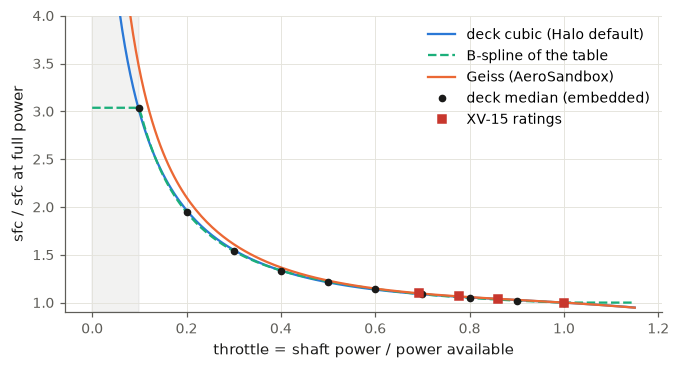

In [11]:
from examples.xv15_performance import part_power_sfc_ratios
print("XV-15 LTC1K-4K ratings (contingency = 100 %): throttle, published sfc ratio, deck-cubic model")
rows = part_power_sfc_ratios(part_power_model=cubic)
for throttle, published, model in rows:
    print(f"  {throttle:.3f}  {published:.3f}  {model:.3f}  ({model / published - 1:+.2%})")
check("deck cubic reproduces the four XV-15 sfc ratios within 3 % (test_decks)", all(abs(m / p - 1) < 0.03 for _, p, m in rows))

grid = np.linspace(0.0, 1.15, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(grid, 1 / cubic.efficiency_ratio(grid), color=blue, label="deck cubic (Halo default)")
ax.plot(grid, [1 / scalar(table.efficiency_ratio(g)) for g in grid], color=aqua, ls="--", label="B-spline of the table")
ax.plot(grid[grid > 0.05], 1 / geiss.efficiency_ratio(grid[grid > 0.05]), color=orange, label="Geiss (AeroSandbox)")
ax.plot(pf, deck_1120hp_sfc_ratio, "o", color=ink, ms=4, label="deck median (embedded)")
ax.plot([r[0] for r in rows], [r[1] for r in rows], "s", color=red, ms=5, label="XV-15 ratings")
ax.axvspan(0, 0.1, color=ink_muted, alpha=0.08)
ax.set(xlabel="throttle = shaft power / power available", ylabel="sfc / sfc at full power", ylim=(0.9, 4.0))
ax.legend(); plt.show()

The cubic and the table agree within 1.4 % over the table range. Outside it they part: below 10 % (shaded) the
cubic keeps falling to an efficiency ratio of 0.115 at t = 0 while the spline holds 0.329; above t = 1 the cubic
*rises* above 1 (1.033 at t = 1.1), so it would credit an engine above its power available with better efficiency.
In the sizing that branch is never reached: every flight point carries the margin shaft power ≤ power available
(`compatibility.py` L150-153).

In [12]:
show_source("src/aircraft_closure/powertrain/components/turboshaft.py", 87, 104)

# src/aircraft_closure/powertrain/components/turboshaft.py  lines 87-104
  87  @dataclass(frozen=True)
  88  class DensityTemperatureLapse:
  89      """Power available / rated = sigma^n (T / T_ISA(h))^-m at pressure altitude h (Tier 16).
  90  
  91      sigma = rho / rho_SL at the point and T_ISA(h) = T - temperature deviation, so the temperature factor is
  92      exactly 1 on a standard day and the model is then the density lapse sigma^n. At fixed pressure altitude a
  93      temperature rise lowers power as (T / T_ISA)^-(n + m): n through density, m directly. m = 0 recovers the
  94      density-only lapse on any day.
  95      """
  96      lapse_exponent: Any = 0.0
  97      lapse_exponent_temperature: Any = 0.0
  98      source: str = ""
  99  
 100      def power_ratio(self, atmosphere):
 101          temperature_K = atmosphere.temperature()
 102          temperature_ratio = temperature_K / (temperature_K - atmosphere.temperature_deviation)
 103          return ((atmosphere.

**L87-104 `DensityTemperatureLapse`** (Tier 16, `docs/decisions/020`). At pressure altitude h:

$$\frac{P_{avail}}{P_{rated}} = \sigma^{\,n} \left(\frac{T}{T_{ISA}(h)}\right)^{-m}, \qquad \sigma = \frac{\rho}{\rho_{SL}}$$

- L101 T is the ambient temperature of the `asb.Atmosphere`, which already includes the deviation;
- L102 T_ISA(h) is recovered as `T - temperature_deviation`. AeroSandbox's `Atmosphere(altitude, temperature_deviation)`
  treats `altitude` as the pressure altitude (pressure follows the standard profile) and adds the deviation to the
  temperature, so density falls on a hot day through ρ = p / (R T);
- on a standard day the deviation is 0, the factor is exactly 1, and the model is the σ^n lapse (docstring L91-93);
- at fixed pressure altitude σ ∝ T_ISA/T, so a hot day lowers power as (T/T_ISA)^-(n+m): n through density, m directly
  (L93). m = 0 recovers the density-only lapse;
- L96-97 the exponents are typed `Any` so they could be design variables; the Halo passes the XV-15 fits (Section 3);
- `source` is provenance text, never read by code.

**Run it** with the sized Halo engine's lapse model (n = 0.797, m = 2.486 from the XV-15 fits).

In [13]:
lapse = engine.lapse_model
print(lapse)
for h_ft, dT in ((0, 0.0), (4000, 0.0), (4000, 20.0), (13000, 0.0)):
    atm = asb.Atmosphere(altitude=h_ft * u.foot, temperature_deviation=dT)
    print(f"{h_ft:6d} ft ISA{dT:+5.1f} K: sigma {atm.density() / ts.density_sea_level_kg_m3:.4f}, "
          f"P_avail/P_rated {lapse.power_ratio(atm):.4f}")
atm_std, atm_hot = asb.Atmosphere(altitude=1219.2), asb.Atmosphere(altitude=1219.2, temperature_deviation=20.0)
sigma_std = atm_std.density() / ts.density_sea_level_kg_m3
check("standard day: power ratio equals sigma^n exactly", abs(lapse.power_ratio(atm_std) - sigma_std**lapse.lapse_exponent) < 1e-14)
hot_over_std = lapse.power_ratio(atm_hot) / lapse.power_ratio(atm_std)
theta = atm_hot.temperature() / atm_std.temperature()
check("hot / standard at same pressure altitude = (T/T_ISA)^-(n+m)",
      abs(hot_over_std - theta**-(lapse.lapse_exponent + lapse.lapse_exponent_temperature)) < 1e-12)
check("m = 0 recovers the density lapse on a hot day", abs(replace(lapse, lapse_exponent_temperature=0.0).power_ratio(atm_hot)
      - (atm_hot.density() / ts.density_sea_level_kg_m3)**lapse.lapse_exponent) < 1e-14)

DensityTemperatureLapse(lapse_exponent=0.7972736016640398, lapse_exponent_temperature=2.4860908011444636, source='XV-15 TM X-62407 fig. 6.2.2, take-off, standard day and 95 F')
     0 ft ISA +0.0 K: sigma 1.0000, P_avail/P_rated 1.0000
  4000 ft ISA +0.0 K: sigma 0.8873, P_avail/P_rated 0.9090
  4000 ft ISA+20.0 K: sigma 0.8282, P_avail/P_rated 0.7251
 13000 ft ISA +0.0 K: sigma 0.6702, P_avail/P_rated 0.7268
PASS  standard day: power ratio equals sigma^n exactly
PASS  hot / standard at same pressure altitude = (T/T_ISA)^-(n+m)
PASS  m = 0 recovers the density lapse on a hot day


In [14]:
show_source("src/aircraft_closure/powertrain/components/turboshaft.py", 107, 159)

# src/aircraft_closure/powertrain/components/turboshaft.py  lines 107-159
 107  @dataclass(frozen=True)
 108  class TurboshaftResult:
 109      power_shaft_W: Any
 110      fuel_flow_kg_s: Any
 111      power_loss_W: Any
 112  
 113  
 114  @dataclass(frozen=True)
 115  class TurboshaftLimits:
 116      power_rated_W: Any
 117  
 118  
 119  @dataclass(frozen=True)
 120  class SimpleTurboshaft:
 121      power_rated_W: Any = 150000.0
 122      specific_power_W_kg: float = 2000.0
 123      thermal_efficiency: float = 0.3
 124      fuel_lower_heating_value_J_kg: float = 43000000.0
 125      lapse_exponent: Any = 0.0
 126      part_power_model: Any = None
 127      mass_kg: Any = None
 128      lapse_model: Any = None          # None: sigma^lapse_exponent; else lapse_model.power_ratio (lapse_exponent unused)
 129  
 130      def get_mass(self):
 131          return self.mass_kg if self.mass_kg is not None else self.power_rated_W / self.specific_power_W_kg
 132  
 133      def power_availa

- **L107-111 `TurboshaftResult`**: shaft power [W] (the input, passed through), fuel flow [kg/s], loss [W]
  (fuel chemical power minus shaft power, i.e. everything that leaves as exhaust heat and tailpipe kinetic energy).
- **L114-116 `TurboshaftLimits`**: one field. Note the name: it is filled with the power **available** at the given
  atmosphere (L142), not the rating, despite being called `power_rated_W`.
- **L119-128 `SimpleTurboshaft` fields.** Defaults are Tier 1: 150 kW, 2 kW/kg, eta 0.30, LHV 43 MJ/kg (Jet A), no
  lapse, no part-power, no explicit mass. `power_rated_W`, `lapse_exponent` and `mass_kg` are `Any` (may be symbolic);
  `thermal_efficiency` is typed `float` but the Halo passes a NumPy float from a regression (and could pass a CasADi
  expression; the annotation is not enforced).
- **L130-131 `get_mass`**: explicit `mass_kg`, else rated power / specific power. One engine; the topology count
  multiplies it.
- **L133-139 `power_available_W(atmosphere)`**:
  - no atmosphere: the rating (L135-136). This is what `get_limits()` without arguments and the static envelope use;
  - a `lapse_model` takes precedence (L137-138), and `lapse_exponent` is then ignored (comment L128);
  - else the density lapse P_rated σ^n (L139). With the default n = 0 this is the rating at every altitude.
- **L141-142 `get_limits`**: wraps power available. In production code nothing calls it: the operating margin in
  `compatibility.py` L150-153 calls `power_available_W(atmosphere)` directly, and the static envelope (L75-77) uses
  `power_rated_W` (Findings).
- **L144-148 `thermal_efficiency_at(P, atmosphere)`**:

$$\eta(P) = \eta_{full}\ \frac{\eta}{\eta_{max}}(t), \qquad t = \frac{P}{P_{avail}(\text{atmosphere})}$$

  throttle is relative to power available *at the point*, because the deck curve was normalized per (Mach, altitude)
  row to that row's maximum. Without an atmosphere, t = P / P_rated.
- **L150-155 `evaluate(P, atmosphere)`**:

$$P_{fuel} = \frac{P}{\eta(P)}, \qquad \dot m_{fuel} = \frac{P_{fuel}}{LHV}, \qquad P_{loss} = P_{fuel} - P$$

  The comment L151-152 states the contract shared by every component: `evaluate` never clips. P > P_avail is
  evaluated as if possible; the caller adds the margin. Everything is closed-form in P, so the whole chain stays
  differentiable and symbolic with no internal solve.
- **L158-159** a smoke test: 100 kW on the default engine.

**Run it** on the sized Halo engine at the take-off hover (sea level, standard day). The baseline reports both
turboshafts together.

In [15]:
seg = ref.segments[0]
print(seg["label"], {k: seg[k] for k in ("duration_s", "fuel_kg", "power_turboshafts_W", "altitude_start_m")})
atm_sl = asb.Atmosphere(altitude=0.0)
power_one_W = seg["power_turboshafts_W"] / counts["turboshaft"]
result = engine.evaluate(power_one_W, atm_sl)
throttle = power_one_W / engine.power_available_W(atm_sl)
eta = engine.thermal_efficiency_at(power_one_W, atm_sl)
fuel_kg = counts["turboshaft"] * result.fuel_flow_kg_s * seg["duration_s"]
print(f"per engine {power_one_W / 1e3:.1f} kW, throttle {throttle:.4f}, eta {eta:.4f} (full {engine.thermal_efficiency:.4f}), "
      f"fuel flow {result.fuel_flow_kg_s * 3600:.1f} kg/h, sfc {result.fuel_flow_kg_s * 3600 / (power_one_W / 1e3):.3f} kg/kWh")
print(f"segment fuel: recomputed {fuel_kg:.3f} kg, baseline {seg['fuel_kg']:.3f} kg")
check("take-off hover fuel reproduced from SimpleTurboshaft.evaluate (0.1 %)", abs(fuel_kg / seg["fuel_kg"] - 1) < 1e-3)
check("loss = fuel chemical power - shaft power",
      abs(result.power_loss_W - (result.fuel_flow_kg_s * engine.fuel_lower_heating_value_J_kg - power_one_W)) < 1e-6)
check("no atmosphere: power available is the rating", engine.power_available_W() == engine.power_rated_W)

hover = ref.hovers[0]
atm_hover = asb.Atmosphere(altitude=hover.altitude_m, temperature_deviation=hover.temperature_offset_K)
available_W = counts["turboshaft"] * engine.power_available_W(atm_hover)
print(f"\n{hover.label} at {hover.altitude_m / u.foot:.0f} ft ISA{hover.temperature_offset_K:+.0f}: two engines available "
      f"{available_W / 1e3:.1f} kW (baseline {hover.power_available_turboshafts_W / 1e3:.1f} kW)")
check("hover power available reproduced", abs(available_W - hover.power_available_turboshafts_W) < 1e-3)

take-off hover {'duration_s': 60.0, 'fuel_kg': 7.530998680805585, 'power_turboshafts_W': 1367087.7715087421, 'altitude_start_m': 0}
per engine 683.5 kW, throttle 0.8184, eta 0.2533 (full 0.2657), fuel flow 225.9 kg/h, sfc 0.331 kg/kWh
segment fuel: recomputed 7.531 kg, baseline 7.531 kg
PASS  take-off hover fuel reproduced from SimpleTurboshaft.evaluate (0.1 %)
PASS  loss = fuel chemical power - shaft power
PASS  no atmosphere: power available is the rating

hover at 4000 ft ISA+0: two engines available 1518.4 kW (baseline 1518.4 kW)
PASS  hover power available reproduced


The fuel matches only if the segment ran on a standard day at sea level, which it does. A 60 s hover is a single
point, so `duration × fuel flow` is the whole segment.

Symbolic use: the engine model is a closed-form chain, so it goes straight into an `asb.Opti`. Here, the largest
shaft power one Halo engine delivers at 13,000 ft on a +20 K day, and the fuel flow there:

In [16]:
opti = asb.Opti()
power_W = opti.variable(init_guess=3e5, scale=1e5, lower_bound=0.0)
atm = asb.Atmosphere(altitude=13000 * u.foot, temperature_deviation=20.0)
opti.subject_to(power_W <= engine.power_available_W(atm))
opti.minimize(-power_W / 1e5)
solution = opti.solve(verbose=False)
fuel_kg_h = solution.value(engine.evaluate(power_W, atm).fuel_flow_kg_s) * 3600
print(f"max power {solution.value(power_W) / u.hp:.0f} hp of {engine.power_rated_W / u.hp:.0f} hp rated; fuel {fuel_kg_h:.1f} kg/h")
check("Opti finds P = P_avail (throttle 1, eta = eta_full)",
      abs(solution.value(power_W) / engine.power_available_W(atm) - 1) < 1e-6)

max power 640 hp of 1120 hp rated; fuel 150.4 kg/h
PASS  Opti finds P = P_avail (throttle 1, eta = eta_full)


---
## 3. Where n and m come from: `xv15_performance.fit_lapse_exponent` and `xv15_hot_day.xv15_lapse_model`

Both are post-processing of fixed digitized data (no Opti), run every time the Halo aircraft is built
(`halo_sizing.py` L639 and L758).

In [17]:
show_source("examples/xv15_performance.py", 32, 52)

# examples/xv15_performance.py  lines 32-52
  32  @dataclass(frozen=True)
  33  class Xv15PowerData:
  34      altitude_power_m: tuple = tuple(h * u.foot for h in (0, 4000, 8000, 12000, 16000, 20000))
  35      power_available_rotor_W: tuple = tuple(p * u.hp for p in (1374, 1285, 1181, 1061, 942, 788))
  36      altitude_hover_m: tuple = tuple(h * u.foot for h in (229, 2214, 4198, 6183, 8168, 10153, 20000))
  37      mass_hover_kg: tuple = tuple(w * u.lbm for w in (15578, 14897, 14225, 13554, 12882, 12211, 8850))
  38      download_fraction_hover: float = 0.07
  39      altitude_hover_ceiling_published_m: float = 8650 * u.foot     # SP-4517, rating not stated
  40      power_ratings_engine_W: tuple = tuple(p * u.hp for p in (1802, 1550, 1401, 1250))
  41      sfc_ratings_lb_hp_h: tuple = (0.564, 0.584, 0.601, 0.622)
  42  
  43  
  44  def density_ratio(altitude_m):
  45      return asb.Atmosphere(altitude=altitude_m).density() / density_sea_level_kg_m3
  46  
  47  
  48  def fit_laps

- **L32-41 `Xv15PowerData`**: digitized from NASA TM X-62407 (1975) fig. 6.2.2, rotor shaft power available per
  engine, take-off rating, helicopter mode, standard day: 1,374 shp at sea level falling to 788 shp at 20,000 ft
  (about +/-15 shp, module docstring L5-6). The 1,374 shp is on a *rotor-shaft* basis: 0.887 of the 1,550 shp engine
  rating (L13-15). L37-41 hold the hover-weight and sfc data used elsewhere.
- **L44-45 `density_ratio`**: σ(h) with the module constant from `turboshaft.py`.
- **L48-52 `fit_lapse_exponent`**: least squares **through the origin** on the log of the lapse law:

$$\ln\frac{P(h)}{P_{SL}} = n \ln\sigma(h) \quad\Rightarrow\quad n = \frac{\sum x_i y_i}{\sum x_i^2}, \quad x_i = \ln\sigma_i,\ y_i = \ln\frac{P_i}{P_{SL}}$$

  - L50-51 the sea-level point (`[1:]`) is excluded: it is the normalizer, and its (0, 0) would add nothing to either
    sum anyway;
  - through the origin because σ^n must be exactly 1 at sea level; a free intercept would break that;
  - fitting in logs weights relative, not absolute, error.
  Plan 012 result: n = 0.797, 3-4 % low between 4 and 12 kft, within 6 % to 20 kft (`docs/decisions/012`).

In [18]:
from examples.xv15_performance import Xv15PowerData, fit_lapse_exponent, density_ratio
data = Xv15PowerData()
n = fit_lapse_exponent()
x_fit = np.log([density_ratio(h) for h in data.altitude_power_m[1:]])
y_fit = np.log(np.array(data.power_available_rotor_W[1:]) / data.power_available_rotor_W[0])
n_polyfit = np.linalg.lstsq(x_fit[:, None], y_fit, rcond=None)[0][0]
print(f"n = {n:.4f} (lstsq through origin {n_polyfit:.4f}); Halo engine uses {engine.lapse_model.lapse_exponent:.4f}")
for h, p in zip(data.altitude_power_m, data.power_available_rotor_W):
    model = data.power_available_rotor_W[0] * density_ratio(h)**n
    print(f"  {h / u.foot:6.0f} ft: digitized {p / u.hp:5.0f} shp, sigma^n model {model / u.hp:5.0f} shp ({model / p - 1:+.1%})")
check("n equals a no-intercept least-squares solve", abs(n - n_polyfit) < 1e-12)
check("n = 0.797 (plan 012) and the Halo engine uses it", abs(n - 0.797) < 5e-4 and engine.lapse_model.lapse_exponent == n)

n = 0.7973 (lstsq through origin 0.7973); Halo engine uses 0.7973
       0 ft: digitized  1374 shp, sigma^n model  1374 shp (+0.0%)
    4000 ft: digitized  1285 shp, sigma^n model  1249 shp (-2.8%)
    8000 ft: digitized  1181 shp, sigma^n model  1132 shp (-4.1%)
   12000 ft: digitized  1061 shp, sigma^n model  1024 shp (-3.5%)
   16000 ft: digitized   942 shp, sigma^n model   925 shp (-1.8%)
   20000 ft: digitized   788 shp, sigma^n model   834 shp (+5.8%)
PASS  n equals a no-intercept least-squares solve
PASS  n = 0.797 (plan 012) and the Halo engine uses it


In [19]:
show_source("examples/xv15_hot_day.py", 31, 76)

# examples/xv15_hot_day.py  lines 31-76
  31  def temperature_from_fahrenheit_K(temperature_F):
  32      return (temperature_F - 32) * 5 / 9 + 273.15
  33  
  34  
  35  def temperature_offset_K(altitude_m, temperature_K):
  36      """Offset from the AeroSandbox standard atmosphere at a pressure altitude that gives this ambient temperature."""
  37      return temperature_K - asb.Atmosphere(altitude=altitude_m).temperature()
  38  
  39  
  40  @dataclass(frozen=True)
  41  class Xv15HotDayData:
  42      temperature_K: float = temperature_from_fahrenheit_K(95.0)
  43      altitude_power_m: tuple = tuple(h * u.foot for h in (0, 2000, 4000, 6000, 8000, 10000, 12000))
  44      power_available_rotor_W: tuple = tuple(p * u.hp for p in (1103, 1021, 941, 864, 791, 720, 647))
  45      altitude_hover_m: tuple = tuple(h * u.foot for h in (229, 2000, 4000, 6000, 8000, 10000, 12000,
  46                                                           14000, 16000, 18000))
  47      mass_hover_kg: t

- **L31-32** °F to K. **L35-37 `temperature_offset_K`**: the ISA deviation that makes the ambient temperature T at
  pressure altitude h, T - T_ISA(h). "T = 95 F" is read as 95 °F at every pressure altitude (module docstring L14), so
  the offset grows with altitude: about +20 K at sea level, about +44 K at 12,000 ft.
- **L40-50 `Xv15HotDayData`**: fig. 6.2.2 dashed 95 °F curve, 1,103 shp at sea level to 647 shp at 12,000 ft, and the
  fig. 5.1.2 hot-day hover weights (used for the prediction check, not the fit).
- **L53-54 `hot_atmosphere`**: an `asb.Atmosphere` at pressure altitude h with that deviation.
- **L57-69 `fit_temperature_lapse_exponent`**. At the same pressure altitude the density lapse contributes
  σ_hot / σ_std = T_ISA / T, so the full model predicts

$$\ln\frac{P_{95F}}{P_{std}} = -(n+m)\,\ln\frac{T}{T_{ISA}}$$

  - L60 n defaults to the standard-day fit;
  - L61-67 pair the two curves at the pressure altitudes they share (0, 4,000, 8,000, 12,000 ft). The pairing is a
    dict lookup on float keys (`h in hot`, L64); it works because both tuples compute `h * u.foot` from the same
    integers, so the floats are bit-identical;
  - L69 least squares through the origin gives n + m, and m = (n + m) - n. Plan 020: n + m = 3.28, residuals under
    0.3 %, m = 2.49 (`docs/decisions/020`).
- **L72-76 `xv15_lapse_model`**: builds `DensityTemperatureLapse(n, m, source=...)`, fitting whichever exponent is not
  given. `build_halo_aircraft` calls `xv15_lapse_model(lapse_exponent)` (L758), so m is re-fitted at every build.

n = 0.7973, m = 2.4861, n + m = 3.283
PASS  Halo engine lapse model is xv15_lapse_model() (same n and m)
PASS  n + m = 3.28 (plan 020)
pressure altitudes paired: [0, 4000, 8000, 12000] ft
PASS  the float-key pairing finds all four shared altitudes


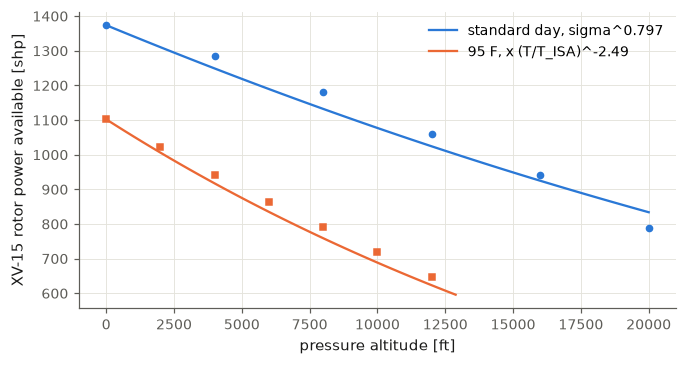

95 F model / digitized - 1: [-0.1 -1.5 -2.5 -3.3 -4.  -4.4 -3.7] %


In [20]:
from examples.xv15_hot_day import Xv15HotDayData, hot_atmosphere, xv15_lapse_model, fit_temperature_lapse_exponent
hot = Xv15HotDayData()
model = xv15_lapse_model()
print(f"n = {model.lapse_exponent:.4f}, m = {model.lapse_exponent_temperature:.4f}, n + m = {model.lapse_exponent + model.lapse_exponent_temperature:.3f}")
check("Halo engine lapse model is xv15_lapse_model() (same n and m)",
      engine.lapse_model.lapse_exponent == model.lapse_exponent
      and engine.lapse_model.lapse_exponent_temperature == model.lapse_exponent_temperature)
check("n + m = 3.28 (plan 020)", abs(model.lapse_exponent + model.lapse_exponent_temperature - 3.28) < 0.005)
paired = [h for h in data.altitude_power_m if h in dict(zip(hot.altitude_power_m, hot.power_available_rotor_W))]
print("pressure altitudes paired:", [round(h / u.foot) for h in paired], "ft")
check("the float-key pairing finds all four shared altitudes", len(paired) == 4)

engine_xv15_std = replace(engine, power_rated_W=data.power_available_rotor_W[0], lapse_model=model)
fig, ax = plt.subplots(figsize=(7, 3.5))
grid_ft = np.linspace(0, 20000, 60)
ax.plot(grid_ft, [engine_xv15_std.power_available_W(asb.Atmosphere(altitude=h * u.foot)) / u.hp for h in grid_ft],
        color=blue, label=f"standard day, sigma^{model.lapse_exponent:.3f}")
ax.plot(grid_ft[grid_ft <= 13000], [engine_xv15_std.power_available_W(hot_atmosphere(h * u.foot)) / u.hp
        for h in grid_ft[grid_ft <= 13000]], color=orange, label=f"95 F, x (T/T_ISA)^-{model.lapse_exponent_temperature:.2f}")
ax.plot(np.array(data.altitude_power_m) / u.foot, np.array(data.power_available_rotor_W) / u.hp, "o", color=blue, ms=4)
ax.plot(np.array(hot.altitude_power_m) / u.foot, np.array(hot.power_available_rotor_W) / u.hp, "s", color=orange, ms=4)
ax.set(xlabel="pressure altitude [ft]", ylabel="XV-15 rotor power available [shp]"); ax.legend(); plt.show()
residuals = [float(engine_xv15_std.power_available_W(hot_atmosphere(h)) / p - 1)
             for h, p in zip(hot.altitude_power_m, hot.power_available_rotor_W)]
print("95 F model / digitized - 1:", np.round(np.array(residuals) * 100, 1), "%")

The 95 °F residuals include the standard-day fit error (the model is σ^n times the temperature factor, and σ^n is
3-4 % low at mid altitude), which is why they are larger than the 0.3 % residuals of the paired *ratio* fit.

---
## 4. `powertrain/components/gearbox.py`

In [21]:
show_source("src/aircraft_closure/powertrain/components/gearbox.py", 1, 52)

# src/aircraft_closure/powertrain/components/gearbox.py  lines 1-52
   1  """Forward power transfer; reduction_ratio = input speed / output speed."""
   2  from dataclasses import dataclass
   3  from typing import Any
   4  
   5  import aerosandbox.numpy as np
   6  
   7  
   8  @dataclass(frozen=True)
   9  class GearStageModel:
  10      """Stage count, efficiency and relative mass of a gear train from its overall ratio (plan 033).
  11  
  12      The ratio is fast / slow, at least 1, for reductions and step-ups alike. With x = ln(ratio) / ln(ratio_max_stage),
  13      the stage count is a smooth ceil(x), at least 1:
  14      - staircase: 1 + sum_k sigmoid((x - k) / width - 3), k = 1..count_stages_max. Each step is centred 3 widths
  15        past the integer, so count_stages(ratio_max_stage) = 1 + sigmoid(-3) = 1.047;
  16      - relaxed (`staircase` False): 1 + width softplus((x - 1) / width), a smooth max(1, x).
  17  
  18      Efficiency is efficiency_fixed (1 - loss_stag

- **L1** the module convention: `reduction_ratio` = input speed / output speed. A step-up gearbox (the generator's)
  therefore has `reduction_ratio` < 1.
- **L8-29 `GearStageModel` docstring** (plan 033, `docs/decisions/033`). The stage model takes the **fast/slow**
  ratio, always ≥ 1, so it treats a reduction and a step-up alike (L12).
- **L30-37 fields.** Max ratio per stage 5:1 (L27-28: simple planetary 3-10:1, OH-58 planetary 4.67:1, H3X 6.7:1);
  loss per stage 1 % (a mesh pair, 0.5 % per mesh); fixed efficiency 0.99 (bearings, seals, churning); 30 % extra mass
  per extra stage; staircase on by default; step width 0.02; relaxed width 0.05; at most 6 stages in the staircase.
  The Halo uses `staircase=False` (halo_sizing L405).
- **L39-45 `count_stages(ratio)`.** With

$$x = \frac{\ln r}{\ln r_{max,stage}}$$

  x is the number of max-ratio stages needed (r = 5 gives x = 1, r = 25 gives x = 2). The integer stage count would be
  max(1, ceil(x)), which is non-smooth. Two smooth forms:
  - **staircase** (L41-44): a sum of sigmoids, one step per integer k = 1..6,

$$n = 1 + \sum_{k=1}^{6} \text{sigmoid}\!\left(\frac{x - k}{w} - 3\right), \quad w = 0.02$$

    Each step is centred at x = k + 3w, three widths *past* the integer, so at exactly r = 5 the count is
    1 + sigmoid(-3) = 1.047 (docstring L15) and a ratio just above 5 is already counted as 2 stages. The sigmoid is
    written as (1 + tanh(z/2))/2 (L42-44), which is algebraically identical but cannot overflow: `exp(-z)` at
    z = -150 (x far from k) would overflow to inf, `tanh` saturates at ±1;
  - **relaxed** (L45): 1 + w·softplus((x - 1)/w), w = 0.05, a smooth max(1, x). It is never an integer above 1: a
    12:1 box counts 1.54 stages. This is the Halo default because the staircase's plateaus create one local optimum
    per stage count and failed the AeroBuildup and thermal warm starts (halo_sizing L403-405, plan 033). The sizing
    keeps a two-start fallback for the staircase (halo_sizing L1036-1056).
- **L47-48 `efficiency`**: η = 0.99 (1 - 0.01)^n. Integer n = 1, 2, 3 gives 0.980, 0.970, 0.961 (docstring L22); the
  Tier 13 constant was 0.97. n enters as a real exponent, so a fractional count gives an interpolated efficiency.
- **L50-51 `mass_factor`**: 1 + 0.3 (n - 1), relative to a one-stage drive. Docstring L24-26: an upstream stage
  carries 1/r of the output torque; with AFDD's power exponent 0.78, (1/5)^0.78 = 0.28 of the output stage's mass,
  plus its own bearings and housing, so 0.3.

**Run it**

ratio   x      stair   relaxed  eta(relaxed)  mass factor(relaxed)
   1.0  0.000  1.000   1.000    0.9801       1.000
   3.0  0.683  1.000   1.000    0.9801       1.000
   5.0  1.000  1.047   1.035    0.9798       1.010
   5.2  1.024  1.144   1.048    0.9796       1.014
   6.0  1.113  1.935   1.118    0.9789       1.035
  12.0  1.544  2.000   1.544    0.9748       1.163
  25.0  2.000  2.047   2.000    0.9703       1.300
  35.4  2.216  3.000   2.216    0.9682       1.365
 125.0  3.000  3.047   3.000    0.9606       1.600
PASS  staircase at r = 5 is 1 + sigmoid(-3) = 1.047 (L15)
PASS  staircase is near-integer between steps (r = 12 -> 2, r = 35.4 -> 3)
PASS  integer-stage efficiencies 0.980 / 0.970 / 0.961 (L22)
PASS  relaxed count tends to max(1, x): 1 at r = 1, x at r = 125
PASS  tanh-form sigmoid does not overflow far from the step
symbolic count: MX


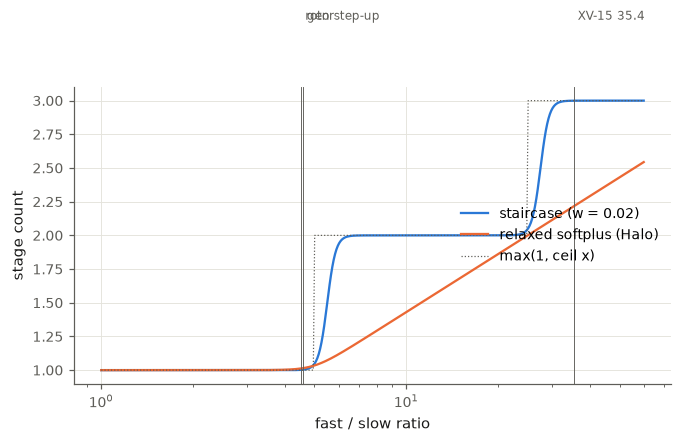

In [22]:
from aircraft_closure.powertrain.components.gearbox import Gearbox, GearStageModel
stair, relaxed = GearStageModel(), GearStageModel(staircase=False)
print("ratio   x      stair   relaxed  eta(relaxed)  mass factor(relaxed)")
for r in (1.0, 3.0, 5.0, 5.2, 6.0, 12.0, 25.0, 35.4, 125.0):
    print(f"{r:6.1f}  {np.log(r) / np.log(5):.3f}  {stair.count_stages(r):.3f}   {relaxed.count_stages(r):.3f}    "
          f"{relaxed.efficiency(r):.4f}       {relaxed.mass_factor(r):.3f}")
check("staircase at r = 5 is 1 + sigmoid(-3) = 1.047 (L15)", abs(stair.count_stages(5.0) - (1 + 1 / (1 + np.exp(3)))) < 1e-12)
check("staircase is near-integer between steps (r = 12 -> 2, r = 35.4 -> 3)",
      abs(stair.count_stages(12.0) - 2) < 1e-3 and abs(stair.count_stages(35.4) - 3) < 1e-3)
check("integer-stage efficiencies 0.980 / 0.970 / 0.961 (L22)",
      [round(0.99 * 0.99**k, 3) for k in (1, 2, 3)] == [0.980, 0.970, 0.961])
check("relaxed count tends to max(1, x): 1 at r = 1, x at r = 125", abs(relaxed.count_stages(1.0) - 1) < 1e-8
      and abs(relaxed.count_stages(125.0) - 3) < 1e-8)
check("tanh-form sigmoid does not overflow far from the step", np.isfinite(stair.count_stages(1e6)))
opti = asb.Opti(); ratio = opti.variable(init_guess=8.0, lower_bound=1.5, upper_bound=40.0)
print("symbolic count:", type(relaxed.count_stages(ratio)).__name__)

grid_r = np.geomspace(1, 60, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(grid_r, stair.count_stages(grid_r), color=blue, label="staircase (w = 0.02)")
ax.plot(grid_r, relaxed.count_stages(grid_r), color=orange, label="relaxed softplus (Halo)")
ax.plot(grid_r, np.maximum(1, np.ceil(np.log(grid_r) / np.log(5) - 1e-9)), color=ink_muted, lw=0.8, ls=":", label="max(1, ceil x)")
for label, r_mark in (("rotor", gearbox.reduction_ratio), ("gen step-up", 1 / generator_gearbox.reduction_ratio), ("XV-15 35.4", 35.4)):
    ax.axvline(r_mark, color=ink_muted, lw=0.6); ax.text(r_mark * 1.03, 3.6, label, fontsize=8, color=ink_muted)
ax.set(xscale="log", xlabel="fast / slow ratio", ylabel="stage count"); ax.legend(loc="center right"); plt.show()

In [23]:
show_source("src/aircraft_closure/powertrain/components/gearbox.py", 54, 92)

# src/aircraft_closure/powertrain/components/gearbox.py  lines 54-92
  54  @dataclass(frozen=True)
  55  class GearboxResult:
  56      speed_output_rad_s: Any
  57      torque_output_Nm: Any
  58      power_input_W: Any
  59      power_output_W: Any
  60      power_loss_W: Any
  61  
  62  
  63  @dataclass(frozen=True)
  64  class GearboxLimits:
  65      power_rated_W: Any
  66  
  67  
  68  @dataclass(frozen=True)
  69  class Gearbox:
  70      reduction_ratio: Any = 4.0
  71      efficiency: float = 0.97
  72      power_rated_W: Any = 100000.0
  73      specific_power_W_kg: float = 10000.0
  74  
  75      def get_mass(self):
  76          return self.power_rated_W / self.specific_power_W_kg
  77  
  78      def get_limits(self):
  79          return GearboxLimits(self.power_rated_W)
  80  
  81      def evaluate(self, speed_input_rad_s, torque_input_Nm):
  82          # Reduction increases torque and decreases speed, with loss deducted
  83          # from torque so the output s

- **L54-60 `GearboxResult`**: output speed and torque, input and output power, loss, all in SI.
- **L63-65 `GearboxLimits`** and **L78-79 `get_limits`**: the rating. The operating margin is on **input** power
  (`compatibility.py` L154-157); the static envelope gives the output port `power_rated_W × efficiency` (L80-84).
- **L68-73 fields**: default ratio 4, efficiency 0.97 (the Tier 13 constant), rating 100 kW, 10 kW/kg. `efficiency` is
  typed `float` but the Halo passes `GearStageModel.efficiency(ratio)`, which is a CasADi expression during sizing
  because the ratio is a design variable.
- **L75-76 `get_mass`**: rating / specific power. The Halo does not use a specific power from data: it computes the
  AFDD mass and back-solves `specific_power_W_kg = P_rated / mass` (Section 5), so `get_mass()` returns the AFDD mass.
- **L81-88 `evaluate(ω_in, Q_in)`**:

$$\omega_{out} = \frac{\omega_{in}}{r}, \qquad Q_{out} = Q_{in}\, r\, \eta, \qquad P_{out} = \eta P_{in}, \qquad P_{loss} = (1-\eta) P_{in}$$

  The loss is taken from torque (comment L82-83), so speed is pure kinematics and P_out = ω_out Q_out holds exactly.
  The flight point uses the inverse: it knows rotor power and speed, sets ω_in = r ω_rotor and
  Q_in = P_rotor / (η ω_in) (`flight_point.py` L226-228). One efficiency applies at all loads (no load-dependent
  churning). Power is assumed to flow input to output ("forward power transfer", L1): with negative power (a
  windmilling rotor driving the motor) the formula still removes (1 - η)·P_in from a negative number, i.e. it
  *adds* power. The Halo never runs a rotor in regeneration, so this is a limit, not a live bug.
- **L91-92** smoke test.

**Run it** on the sized Halo rotor gearbox at the take-off hover motor operating point, and on the step-up gearbox.

In [24]:
speed_motor, torque_motor = seg["speed_motor_rad_s"], seg["torque_motor_Nm"]
lanes = counts["motor"] // counts["gearbox"]
gear = gearbox.evaluate(speed_motor, lanes * torque_motor)       # lanes combine on the gearbox input
print(f"input {speed_motor:.1f} rad/s x {lanes} x {torque_motor:.0f} Nm -> output {gear.speed_output_rad_s:.2f} rad/s, "
      f"{gear.torque_output_Nm:.0f} Nm, {gear.power_output_W / 1e3:.1f} kW, loss {gear.power_loss_W / 1e3:.1f} kW")
check("P_out = omega_out * Q_out exactly", abs(gear.power_output_W - gear.speed_output_rad_s * gear.torque_output_Nm) < 1e-6)
check("energy balance P_in = P_out + loss", abs(gear.power_input_W - gear.power_output_W - gear.power_loss_W) < 1e-6)
rotors_W = counts["gearbox"] * gear.power_output_W
print(f"two rotors: {rotors_W / 1e3:.1f} kW (baseline segment power_rotors_W {seg['power_rotors_W'] / 1e3:.1f} kW)")
check("gearbox output x 2 rotors reproduces the take-off rotor power (0.1 %)", abs(rotors_W / seg["power_rotors_W"] - 1) < 1e-3)

engine_shaft_W = power_one_W
w_engine = assumptions.speed_output_turboshaft_rad_s
step = generator_gearbox.evaluate(w_engine, engine_shaft_W / w_engine)
print(f"step-up: engine {w_engine / u.rpm:.0f} rpm -> generator {step.speed_output_rad_s / u.rpm:.0f} rpm, "
      f"{step.power_output_W / 1e3:.1f} kW to the generator")
check("step-up output speed is the generator design speed", abs(step.speed_output_rad_s - d.speed_peak_generator_rad_s) < 1e-9)

input 205.2 rad/s x 2 x 1616 Nm -> output 45.31 rad/s, 14342 Nm, 649.9 kW, loss 13.3 kW
PASS  P_out = omega_out * Q_out exactly
PASS  energy balance P_in = P_out + loss
two rotors: 1299.8 kW (baseline segment power_rotors_W 1299.8 kW)
PASS  gearbox output x 2 rotors reproduces the take-off rotor power (0.1 %)
step-up: engine 1210 rpm -> generator 5543 rpm, 669.8 kW to the generator
PASS  step-up output speed is the generator design speed


---
## 5. How the Halo builds these components: `examples/halo_sizing.py`

The relevant assumption fields first (engine fixed at 1,120 hp, engine output shaft speed, part-power model,
temperature lapse, gearbox stages).

In [25]:
show_source("examples/halo_sizing.py", 185, 187)
show_source("examples/halo_sizing.py", 199, 201)
show_source("examples/halo_sizing.py", 224, 229)
show_source("examples/halo_sizing.py", 397, 406)

# examples/halo_sizing.py  lines 185-187
 185      # Plan 017 (decided 2026-10-03): off-the-shelf turboshafts, power fixed by the engine deck (1,120 hp SLS, the
 186      # user-supplied GASP_TS deck); a non-OEM cannot raise power available. None restores a sized (rubber) engine.
 187      power_rated_turboshaft_fixed_W: Any = 1120 * u.hp
# examples/halo_sizing.py  lines 199-201
 199      generator_step_up: bool = True                     # step-up gearbox from the engine's output shaft
 200      speed_output_turboshaft_rad_s: float = 1210 * u.rpm  # deck propeller_rpm: the engine as delivered (non-OEM)
 201      direct_drive_rotor: bool = False                   # True: no rotor gearbox, motor turns at rotor speed
# examples/halo_sizing.py  lines 224-229
 224      # Part-power fuel curve: the author-supplied 1,120 hp GASP deck (plan 014); GeissPartPowerModel() is the
 225      # XV-15-validated alternative (within 1 % of it above 50 % power).
 226      part_power_model: Any = field(de

- **L185-187** plan 017 (`docs/decisions/017`): off-the-shelf engines at the deck's 1,120 hp SLS rating; "a non-OEM
  cannot raise power available". `None` restores a rubber engine (rating as a design variable).
- **L199-200** generator step-up on, and the engine's output shaft at the deck's `propeller_rpm`, 1,210 rpm, fixed:
  there is no turbine speed variable.
- **L224-229** the deck cubic is the default part-power model; Geiss is the XV-15-validated alternative (within 1 %
  above 50 % power). Temperature lapse on.
- **L397-406** gearbox stages on (plan 035 default), relaxed count, rotor gear ratio bounded by 40.

In [26]:
show_source("examples/halo_sizing.py", 624, 641)

# examples/halo_sizing.py  lines 624-641
 624  def ratio_reference_gear_stages():
 625      """The XV-15 engine-to-rotor ratio (20,000 / 565 rpm, 35.4:1), where the AFDD transmission factor is calibrated."""
 626      reference = Xv15Reference()
 627      return reference.speed_engine_rad_s / reference.speed_rotor_hover_rad_s
 628  
 629  
 630  def stage_mass_ratio(stage_model, ratio):
 631      """Plan 033: drive mass relative to the AFDD drive at the XV-15 calibration ratio; `ratio` is fast/slow (>= 1)."""
 632      return stage_model.mass_factor(ratio) / stage_model.mass_factor(ratio_reference_gear_stages())
 633  
 634  
 635  def build_halo_aircraft(design, requirements=HaloRequirements(), assumptions=HaloAssumptions(), factors=None,
 636                          lapse_exponent=None):
 637      a, d = assumptions, design
 638      factors = factors if factors is not None else calibration_factors()
 639      lapse_exponent = lapse_exponent if lapse_exponent is not None else fit_la

- **L624-627 `ratio_reference_gear_stages()`**: the XV-15 engine-to-rotor ratio, 20,000 / 565 rpm = 35.4:1, from
  `Xv15Reference`. The XV-15 calibration factor `factors.transmission` was computed at this ratio (plan 011), so it is
  the anchor for the stage scaling.
- **L630-632 `stage_mass_ratio(stage_model, ratio)`**: mass_factor(r) / mass_factor(35.4). With the relaxed model
  mass_factor(35.4) = 1.365 (2.22 stages), so a single-stage Halo box is about 0.73 of the AFDD mass at the XV-15
  ratio.
- **L635-639**: `lapse_exponent` defaults to `fit_lapse_exponent()`; `solve_halo_sizing` passes it in (L1081, L1188).
  `factors` are the XV-15 calibration factors (`xv15_reference.calibration_factors`).

In [27]:
show_source("examples/halo_sizing.py", 690, 742)

# examples/halo_sizing.py  lines 690-742
 690      # Tier 19: with thermal machines the drive is rated on its own (the motor's rating is continuous).
 691      # Tier 18: `motor` is one lane motor; the drive takes all of a rotor's lanes.
 692      lanes = count_lanes_motor(a)
 693      power_rated_gearbox_W = (d.power_rated_gearbox_W if a.thermal_model and d.power_rated_gearbox_W is not None
 694                               else (motor.power_rated_W if lanes == 1 else lanes * motor.power_rated_W))
 695      radius_m = np.sqrt(d.area_disk_m2 / np.pi)
 696      solidity = d.solidity if d.solidity is not None else a.solidity
 697      speed_tip_m_s = d.speed_tip_m_s if d.speed_tip_m_s is not None else a.speed_tip_m_s
 698      chord_m = solidity * np.pi * radius_m / a.count_blades
 699      speed_rotor_design_rad_s = speed_tip_m_s / radius_m
 700      mass_rotors_kg = factors.rotor * afdd.mass_rotor_group_afdd82_kg(a.count_rotors, a.count_blades, radius_m, chord_m,
 701                 

**Rotor gearbox (L690-725).**
- **L692-694 rating**: with the thermal model on (Halo default) the gearbox rating is its own design variable
  `d.power_rated_gearbox_W` (Tier 19), because the motor rating becomes continuous; otherwise it is the motor rating
  times the lanes per rotor (Tier 18).
- **L699** design rotor speed ω_rotor = V_tip / R.
- **L702-705 direct drive**: a pass-through gearbox (ratio 1, η = 1, 1e12 W/kg so its mass is about zero) keeps the
  topology identical. Off by default.
- **L707-711 AFDD input speed.** With stages, the AFDD00 regression is evaluated at **ω_rotor × 35.4**, not at the
  real motor speed (comment L708-709): AFDD00's own ratio dependence (input-speed exponent 0.099) would otherwise be
  counted on top of the stage factor. Without stages, the real motor speed is used.
- **L712-719 AFDD mass of the whole drive** (`weights/afdd.py`, NDARC ch. 19), times the XV-15 transmission factor.
  AFDD00 (L714-715, used with torque-sized machines):

$$m_{gb} = 95.76\ N_{rotor}^{0.386}\ \left(\frac{P_{drive}}{\text{hp}}\right)^{0.781} \left(\frac{\omega_{in}}{\text{rpm}}\right)^{0.099} \left(\frac{\omega_{rotor}}{\text{rpm}}\right)^{-0.807}\ \text{lb}$$

  with P_drive = N_rotor × rating (the whole drive). The −0.807 rotor-speed exponent is the torque dependence: a slow
  rotor needs a heavy box. AFDD83 (L717-719) is the older form used without torque-sized machines (0.6 = second-rotor
  torque fraction).
- **L720-723** with stages: mass × `stage_mass_ratio(stages, r)` and η = `stages.efficiency(r)`. Otherwise
  `efficiency` stays empty and the class default 0.97 applies.
- **L724-725** the component. AFDD gives the mass of *all* gearboxes; dividing by `count_rotors` gives one gearbox,
  and the specific power is back-solved so `get_mass()` returns it.

**Generator step-up gearbox (L726-742).** Built only with torque-sized machines, the step-up switch, and a generator
speed in the design (L727).
- **L729** ratio_step_up = ω_gen / ω_engine ≥ 1 (the design variable's lower bound is the engine speed, L1140-1143),
  as `GearStageModel` requires.
- **L732-734** AFDD00 with one "rotor", the engine rating as drive power, the **engine shaft as the slow side** and
  the input speed again held at 35.4 × slow, then the stage factor at the step-up ratio. The mass therefore does not
  depend on the generator speed except through the stage count.
- **L737-738** without stages: AFDD00 with the generator speed as the fast side.
- **L739-742** `reduction_ratio = ω_engine / ω_gen` (< 1, the module's input/output convention), rated at the engine
  rating, one box per engine (no division by a count).

In [28]:
from aircraft_closure.weights import afdd
from examples.halo_sizing import ratio_reference_gear_stages, stage_mass_ratio
from examples.xv15_reference import calibration_factors, Xv15Reference
factors = calibration_factors()
stages = assumptions.gear_stage_model
ref_ratio = ratio_reference_gear_stages()
xv = Xv15Reference()
print(f"reference ratio {xv.speed_engine_rad_s / u.rpm:.0f} / {xv.speed_rotor_hover_rad_s / u.rpm:.0f} rpm = {ref_ratio:.3f}; "
      f"transmission factor {factors.transmission:.4f}")
radius_m = np.sqrt(d.area_disk_m2 / np.pi)
omega_rotor = d.speed_tip_m_s / radius_m
n_rotor = assumptions.count_rotors
m_afdd = factors.transmission * afdd.mass_gearbox_rotor_shaft_afdd00_kg(n_rotor, n_rotor * d.power_rated_gearbox_W,
                                                                        omega_rotor * ref_ratio, omega_rotor)
ratio_factor = stage_mass_ratio(stages, d.reduction_ratio)
print(f"rotor: omega_rotor {omega_rotor / u.rpm:.1f} rpm, AFDD at 35.4:1 {m_afdd:.1f} kg for {n_rotor} boxes, "
      f"stage ratio {stages.mass_factor(d.reduction_ratio):.4f} / {stages.mass_factor(ref_ratio):.4f} = {ratio_factor:.4f}")
print(f"  -> {m_afdd * ratio_factor / n_rotor:.2f} kg per box; component {gearbox.get_mass():.2f} kg")
check("rotor gearbox mass = AFDD00 at 35.4:1 x stage ratio / rotors", abs(m_afdd * ratio_factor / n_rotor - gearbox.get_mass()) < 1e-9)
check("rotor gearbox eta = stages.efficiency(design ratio)", abs(gearbox.efficiency - stages.efficiency(d.reduction_ratio)) < 1e-15)
check("Halo rotor box counts as one stage (ratio < 5)", d.reduction_ratio < 5 and abs(stages.count_stages(d.reduction_ratio) - 1) < 0.02)
m_real_speed = factors.transmission * afdd.mass_gearbox_rotor_shaft_afdd00_kg(n_rotor, n_rotor * d.power_rated_gearbox_W,
                                                                              d.speed_peak_motor_rad_s, omega_rotor) / n_rotor
print(f"  (AFDD alone at the real motor speed, no stage model: {m_real_speed:.1f} kg per box)")

ratio_up = d.speed_peak_generator_rad_s / w_engine
m_gen = factors.transmission * afdd.mass_gearbox_rotor_shaft_afdd00_kg(1, d.power_rated_turboshaft_W, w_engine * ref_ratio, w_engine) \
    * stage_mass_ratio(stages, ratio_up)
print(f"step-up: {w_engine / u.rpm:.0f} -> {d.speed_peak_generator_rad_s / u.rpm:.0f} rpm, ratio {ratio_up:.3f}, "
      f"stages {stages.count_stages(ratio_up):.4f}, mass {m_gen:.2f} kg (component {generator_gearbox.get_mass():.2f} kg)")
check("step-up mass = AFDD00 (engine shaft as slow side) x stage ratio", abs(m_gen - generator_gearbox.get_mass()) < 1e-9)
check("step-up reduction_ratio = engine / generator speed < 1", abs(generator_gearbox.reduction_ratio - 1 / ratio_up) < 1e-15
      and generator_gearbox.reduction_ratio < 1)
check("powertrain mass table: gearboxes = 2 x per-box mass",
      abs(dict(ref.powertrain_masses_kg)["gearbox"] - counts["gearbox"] * gearbox.get_mass()) < 1e-6
      and abs(dict(ref.powertrain_masses_kg)["generator_gearbox"] - counts["generator_gearbox"] * generator_gearbox.get_mass()) < 1e-6)

reference ratio 20000 / 565 rpm = 35.398; transmission factor 0.9988
rotor: omega_rotor 470.7 rpm, AFDD at 35.4:1 397.6 kg for 2 boxes, stage ratio 1.0038 / 1.3648 = 0.7355
  -> 146.21 kg per box; component 146.21 kg
PASS  rotor gearbox mass = AFDD00 at 35.4:1 x stage ratio / rotors
PASS  rotor gearbox eta = stages.efficiency(design ratio)
PASS  Halo rotor box counts as one stage (ratio < 5)
  (AFDD alone at the real motor speed, no stage model: 160.8 kg per box)
step-up: 1210 -> 5543 rpm, ratio 4.581, stages 1.0145, mass 72.08 kg (component 72.08 kg)
PASS  step-up mass = AFDD00 (engine shaft as slow side) x stage ratio
PASS  step-up reduction_ratio = engine / generator speed < 1
PASS  powertrain mass table: gearboxes = 2 x per-box mass


In [29]:
show_source("examples/halo_sizing.py", 743, 758)

# examples/halo_sizing.py  lines 743-758
 743      if a.rotor_speed_physics:
 744          rotor = MomentumProfileRotor(area_disk_m2=d.area_disk_m2, solidity=solidity, mass_kg=mass_rotors_kg / a.count_rotors,
 745                                       max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
 746                                       speed_tip_max_m_s=speed_tip_m_s)
 747      else:
 748          rotor = ActuatorDiskPropulsor(area_disk_m2=d.area_disk_m2, mass_kg=mass_rotors_kg / a.count_rotors,
 749                                        coefficient_of_performance=a.figure_of_merit,
 750                                        coefficient_of_performance_airplane=a.coefficient_airplane,
 751                                        max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
 752                                        speed_tip_max_m_s=speed_tip_m_s)
 753      battery = build_halo_battery(design, assumptions)
 754      turboshaft = SimpleTurboshaft(pow

- **L743-752** the rotor's `max_shaft_power_W` is the gearbox output rating, `power_rated_W × efficiency`: the same
  number as the gearbox's static output envelope (`compatibility.py` L84).
- **L754-758 the turboshaft.**
  - `power_rated_W` = the fixed 1,120 hp (835.2 kW);
  - `mass_kg` = installed mass, XV-15 powerplant factor × bare mass. The factor (1.145) carries the XV-15 engine
    installation (accessories, mounts, exhaust) the bare regression lacks; `specific_power_W_kg` is therefore unused;
  - `thermal_efficiency` = AeroSandbox `thermal_efficiency_turboshaft(m_bare)`, the full-power efficiency regression
    on mass (with OPR at 0.7 of the technology limit for that mass). A heavier engine is more efficient;
  - `lapse_exponent` and `lapse_model`: both set; with `temperature_lapse` the lapse model wins (L137-138 of the
    component) and on a standard day gives the same σ^n;
  - `part_power_model` = the deck cubic.

In [30]:
show_source("examples/halo_sizing.py", 1116, 1119)
show_source("examples/halo_sizing.py", 1299, 1304)

# examples/halo_sizing.py  lines 1116-1119
1116          power_rated_turboshaft_W=(a.power_rated_turboshaft_fixed_W if a.power_rated_turboshaft_fixed_W is not None
1117                                    else opti.variable(init_guess=guess.power_rated_turboshaft_W, scale=1e6,
1118                                                       lower_bound=5e4)),
1119          mass_turboshaft_bare_kg=opti.variable(init_guess=guess.mass_turboshaft_bare_kg, scale=100.0, lower_bound=10.0),
# examples/halo_sizing.py  lines 1299-1304
1299      opti.subject_to([
1300          mass_takeoff_kg / total.mass == 1,                                           # mass closure
1301          x_cg_m == aircraft.wing.x_le_root_m + 0.25 * aircraft.wing.chord_root_m(),   # hover pitch trim
1302          design.mass_fuel_kg == fuel_factor * flown.mass_fuel_burnt_kg,               # fuel with reserve
1303          power_turboshaft(design.mass_turboshaft_bare_kg) / design.power_rated_turboshaft_W == 1,  # engine regressi

**The engine-mass regression (L1116-1119, L1303).** The rating is a constant (1,120 hp) but the bare mass is still an
`opti.variable` (L1119), tied by an equality to AeroSandbox's power-to-mass regression:

$$\frac{P_{turboshaft}(m_{bare})}{P_{rated}} = 1, \qquad P_{turboshaft}(m) = 1674.9\ m^{0.942}\ \text{OPR}(m)^{0.509}\ \text{W}$$

with OPR(m) = 0.7 × the technology-limit OPR, a `np.blend` of log10(m). With a fixed rating this is one equation in
one unknown, so m_bare is a constant the solver finds implicitly (no inverse function exists in closed form, so the
equality replaces a root-find in Python). Written as a ratio = 1 so the residual is order one. With a rubber engine
(`power_rated_turboshaft_fixed_W=None`) the same equality links rating and mass. The result reports the residual
(`turboshaft_mass_power_residual`, L1353).

Reproduce it outside the sizing with a one-variable Opti:

In [31]:
from aerosandbox.library.power_turboshaft import power_turboshaft, thermal_efficiency_turboshaft
opti = asb.Opti()
m_bare = opti.variable(init_guess=230.0, scale=100.0, lower_bound=10.0)
opti.subject_to(power_turboshaft(m_bare) / (1120 * u.hp) == 1)
m_solved = opti.solve(verbose=False).value(m_bare)
print(f"bare mass {m_solved:.3f} kg (baseline {d.mass_turboshaft_bare_kg:.3f} kg), eta_full {thermal_efficiency_turboshaft(m_solved):.4f}")
print(f"installed {factors.powerplant:.4f} x {d.mass_turboshaft_bare_kg:.2f} = {engine.get_mass():.2f} kg; "
      f"residual in result {ref.turboshaft_mass_power_residual:.1e}")
check("one-variable Opti reproduces the sized bare engine mass", abs(m_solved - d.mass_turboshaft_bare_kg) < 1e-3)
check("engine eta_full = thermal_efficiency_turboshaft(bare mass)",
      abs(engine.thermal_efficiency - thermal_efficiency_turboshaft(d.mass_turboshaft_bare_kg)) < 1e-12)
check("installed mass = powerplant factor x bare", abs(engine.get_mass() - factors.powerplant * d.mass_turboshaft_bare_kg) < 1e-9)
check("rating is the fixed 1,120 hp", abs(engine.power_rated_W - 1120 * u.hp) < 1e-9)

bare mass 184.207 kg (baseline 184.207 kg), eta_full 0.2657
installed 1.1447 x 184.21 = 210.86 kg; residual in result -1.1e-16
PASS  one-variable Opti reproduces the sized bare engine mass
PASS  engine eta_full = thermal_efficiency_turboshaft(bare mass)
PASS  installed mass = powerplant factor x bare
PASS  rating is the fixed 1,120 hp


---
## Gotchas

- **Throttle is P / P_available at the point**, not P / P_rated. At 13,000 ft the same shaft power is a higher
  throttle (better efficiency) than at sea level. The penalty depends on altitude only through power available.
- **The cubic is only meaningful on [0.1, 1].** Below 0.1 it keeps dropping (efficiency ratio 0.115 at idle-zero);
  above 1 it exceeds 1. The power-available margin keeps the sizing inside the upper end; nothing guards the lower end.
- **`lapse_model` silently overrides `lapse_exponent`.** The Halo sets both to the same n, so the result is
  consistent, but changing only `lapse_exponent` on a Halo engine does nothing.
- **`TurboshaftLimits.power_rated_W` holds power available**, and the static compatibility envelope uses the sea-level
  rating. Altitude effects live only in the per-point margin.
- **Gearbox `reduction_ratio` is input/output; `GearStageModel` takes fast/slow.** For the step-up box these are
  reciprocals (0.218 vs 4.58). Passing the step-up's `reduction_ratio` to the stage model would give a count of 1
  and hide the error.
- **With stages on, AFDD is evaluated at 35.4:1**, not at the actual motor speed. The gear-ratio trade enters the mass
  only through the stage factor (and through rotor speed in AFDD).
- **The relaxed stage count is not an integer.** The Halo rotor ratio 4.53 is one stage (1.013); a ratio of 12 would
  be reported as 1.54 stages, with mass and efficiency interpolated between one and two stages.
- **Gearbox losses are not cooled by the sized heat exchanger** (`sources_excluded_heat_exchanger`, halo_sizing L368):
  their oil coolers are assumed inside the AFDD mass.

## Limits / what it can't do

- Turboshaft: one density exponent and one temperature exponent for all ratings; no Mach or ram effect; no tailpipe
  thrust (the deck column is loaded and dropped); no exhaust heat in the thermal model; no turbine speed, torque or
  temperature limits; no contingency rating (`digest_powertrain` 6.6; `docs/decisions/014`, `020`).
- The deck's absolute power versus altitude and Mach is not used (non-monotonic after correction, plan 014).
- Gearbox: constant efficiency (no load dependence), power-only envelope (no torque or speed limit), forward power
  flow only, no clutch or combiner mass for multiple lanes (assumed in AFDD, plan 032), integer stage count deferred.

## What's next (from the docs)

- Deck altitude and Mach behaviour once the `.eng` correction convention is known, tailpipe thrust, re-scaling
  (`docs/decisions/014` out of scope).
- Rating-specific temperature sensitivity (`docs/decisions/020`).
- Discrete enumeration of gearbox stage counts, one solve per count (`docs/decisions/033` out of scope).

## Findings

1. **Unused production API.** `SimpleTurboshaft.get_limits()` / `TurboshaftLimits` (turboshaft.py L114-116,
   L141-142) are not called anywhere in `src/` or `examples/` (grep `TurboshaftLimits`, `get_limits(`): the
   operating margin calls `power_available_W(atmosphere)` directly (`compatibility.py` L150-153). Its single field is
   named `power_rated_W` but holds power *available*.
2. **Static envelope vs operating margin.** `compatibility.py` L75-77 gives the turboshaft shaft envelope
   `max_power_W = power_rated_W` (sea level), while the operating margin uses power available at the point. Not a bug
   in the sizing (the margin is what constrains), but the static report overstates engine capability at altitude.
3. **File handle not closed.** `decks.load_gasp_turboshaft_deck` iterates `open(path, ...)` without `with`
   (decks.py L43). Offline, harmless.
4. **Fragile exact-float matching.** `TurboshaftDeck.row` masks with `==` on floats (decks.py L33) and
   `fit_temperature_lapse_exponent` pairs altitudes with `h in hot` on float keys (xv15_hot_day.py L61-64). Both work
   only because the floats come from identical computations.
5. **Cubic not clamped.** `CubicPartPowerModel` extrapolates below 10 % and above 100 % (efficiency ratio 0.115 at
   t = 0, > 1 above t = 1), unlike `TabulatedPartPowerModel`, which holds its ends. The docstring L63 says "smooth
   everywhere", which is true, but not "valid everywhere".
6. **`Gearbox.evaluate` with reverse power** adds power instead of removing a loss (L81-88). Unreached in the Halo.
7. **Dead-on-arrival models in production.** `TabulatedPartPowerModel` (L40-58) and `decks.py` as a whole are used only
   by tests and offline derivation; `thrust_tailpipe_N` and `metadata` are loaded but never read.
8. **Type annotations** `thermal_efficiency: float` (turboshaft L123) and `efficiency: float` (gearbox L71) receive
   NumPy floats or CasADi expressions in the Halo. Cosmetic.

## Review questions

<details><summary>Why does the code use sfc / sfc_max from the deck and not the deck's sfc or power levels?</summary>

The deck columns are corrected power and corrected fuel flow. Both carry the same correction, so sfc (their ratio) and
sfc normalized on its own row do not depend on the correction convention, which was in doubt. The absolute power
versus altitude was non-monotonic after correction (plan 014), so the lapse comes from XV-15 data instead.
</details>

<details><summary>Why a cubic and not the B-spline through the table?</summary>

The B-spline stalled the coupled Halo IPOPT solve (3,000 iterations, about 300 s, plan 014) because of the steep
low-power end. The cubic, fixed to 1 at full power and fitted by linear least squares, is within 1.1 % of the table
from 20 to 100 % and 1.4 % at 10 %, and is a cheap smooth polynomial for the solver.
</details>

<details><summary>Derive the temperature exponent fit. Why is it n + m that is fitted?</summary>

At the same pressure altitude, σ_hot / σ_std = T_ISA / T (ideal gas, same pressure). The model ratio is
(T_ISA/T)^n × (T/T_ISA)^-m = (T/T_ISA)^-(n+m). Taking logs gives a line through the origin in ln(T/T_ISA) with slope
-(n+m); least squares gives n + m = 3.28, and n = 0.797 from the standard day leaves m = 2.49.
</details>

<details><summary>The Halo rotor gearbox ratio is a design variable. How does it affect gearbox mass and efficiency?</summary>

Only through `GearStageModel`: the stage count n(r) = 1 + 0.05 softplus((ln r / ln 5 - 1)/0.05) sets mass ×
(1 + 0.3(n-1)) / 1.365 relative to the AFDD00 mass evaluated at the XV-15 ratio 35.4, and η = 0.99 × 0.99^n. AFDD's
own input-speed exponent is neutralized by holding its input speed at 35.4 × rotor speed. At the solved 4.53:1 the box
is one stage (n = 1.013), η = 0.980.
</details>

<details><summary>Why is the engine bare mass an optimization variable if the rating is fixed?</summary>

The AeroSandbox regression gives power as a function of mass, P(m) = 1674.9 m^0.942 OPR(m)^0.509, with no closed-form
inverse. The equality P(m)/P_rated = 1 lets IPOPT find m (184.2 kg) inside the same solve, and keeps the code identical
for the rubber-engine option, where P_rated is also a variable.
</details>

<details><summary>Why is the gearbox loss taken out of torque rather than speed?</summary>

Speed through a gear train is fixed by kinematics (tooth counts): ω_out = ω_in / r exactly. Friction losses appear as
a reduced output torque. Taking the loss from torque keeps P = ω Q exact on both ports, so the connection residuals
(speed equal, torque equal) are consistent with the power balance.
</details>

In [32]:
check_summary()

46 of 46 checks passed
